In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [3]:
df=pd.read_csv("Travel.csv")

In [4]:
## handling spelling mistakes 
df=df.drop('CustomerID',axis=1)
df.Gender=df['Gender'].replace('Fe Male','Female')
df['MaritalStatus']=df['MaritalStatus'].replace('Unmarried','Single')


In [5]:
df.Designation.value_counts()

Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64

## Handling Missing values

In [6]:
print(df.isnull().sum())

print("\n",df.info())

ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ProdTaken                 4888 non-null   int64  
 1   Age                       4662 non-null   float64
 2   TypeofContact             4863 non-null   objec

In [7]:
null_columns=[column for column in df.columns if df[column].isnull().sum()>0]
print(null_columns)

['Age', 'TypeofContact', 'DurationOfPitch', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'NumberOfChildrenVisiting', 'MonthlyIncome']


In [8]:
numeric_null_columns = df[null_columns].select_dtypes(include=['int64', 'float64']).columns
cat_null_columns=df[null_columns].select_dtypes(include=['object']).columns
print(numeric_null_columns)
print(cat_null_columns)

Index(['Age', 'DurationOfPitch', 'NumberOfFollowups', 'PreferredPropertyStar',
       'NumberOfTrips', 'NumberOfChildrenVisiting', 'MonthlyIncome'],
      dtype='object')
Index(['TypeofContact'], dtype='object')


In [9]:
print("Missing Percentage:",)
for feature in numeric_null_columns:
    print(feature,':',np.round(df[feature].isnull().mean()*100,2),'%')
print('TypeofContact',':',np.round(df['TypeofContact'].isnull().mean()*100,2),'%')
    

Missing Percentage:
Age : 4.62 %
DurationOfPitch : 5.14 %
NumberOfFollowups : 0.92 %
PreferredPropertyStar : 0.53 %
NumberOfTrips : 2.86 %
NumberOfChildrenVisiting : 1.35 %
MonthlyIncome : 4.77 %
TypeofContact : 0.51 %


Age 
 count    4662.000000
mean       37.622265
std         9.316387
min        18.000000
25%        31.000000
50%        36.000000
75%        44.000000
max        61.000000
Name: Age, dtype: float64
Missing values: 226
Missing Percentage: 4.62


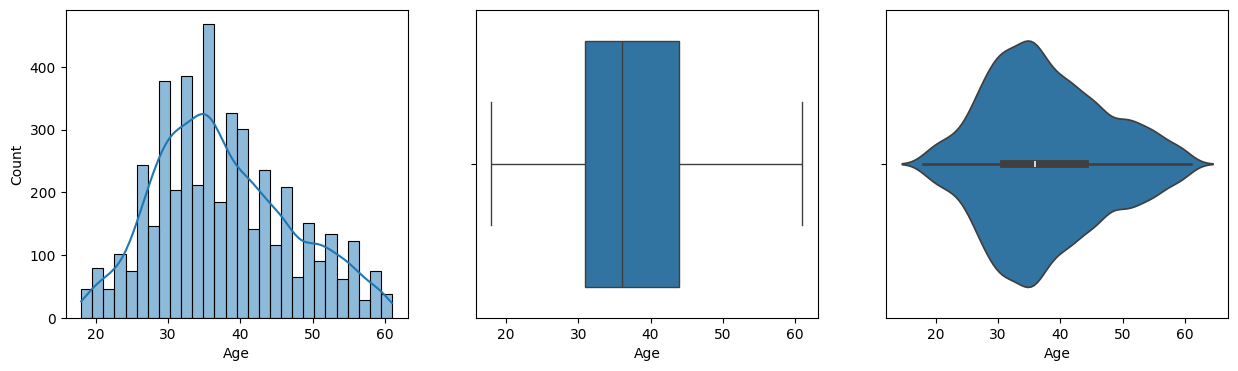

DurationOfPitch 
 count    4637.000000
mean       15.490835
std         8.519643
min         5.000000
25%         9.000000
50%        13.000000
75%        20.000000
max       127.000000
Name: DurationOfPitch, dtype: float64
Missing values: 251
Missing Percentage: 5.14


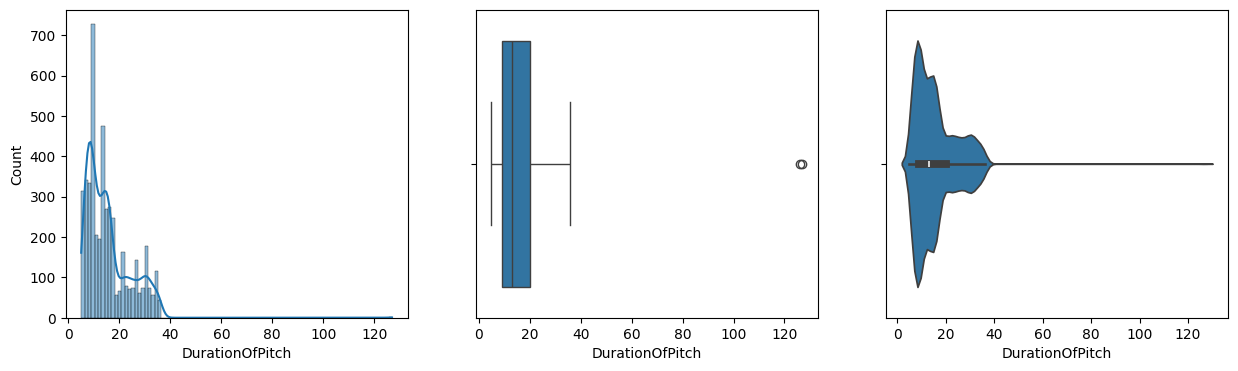

NumberOfFollowups 
 count    4843.000000
mean        3.708445
std         1.002509
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         6.000000
Name: NumberOfFollowups, dtype: float64
Missing values: 45
Missing Percentage: 0.92


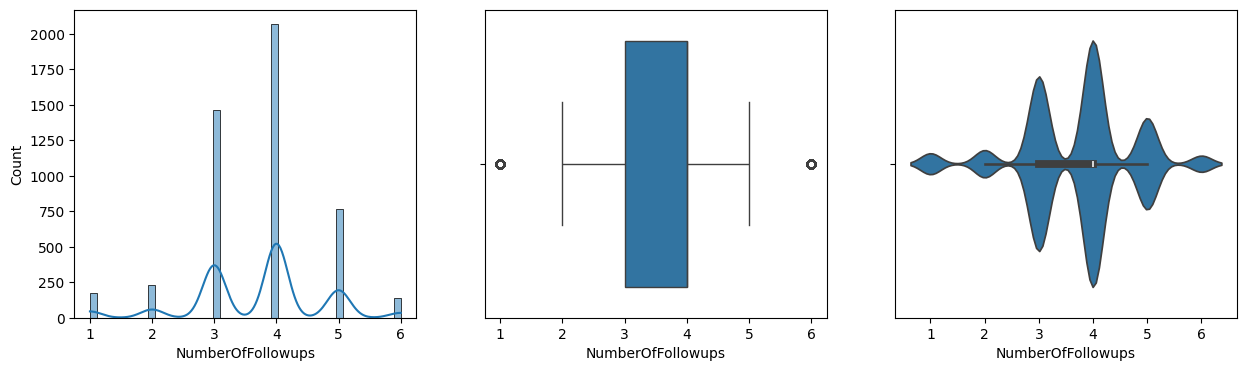

PreferredPropertyStar 
 count    4862.000000
mean        3.581037
std         0.798009
min         3.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: PreferredPropertyStar, dtype: float64
Missing values: 26
Missing Percentage: 0.53


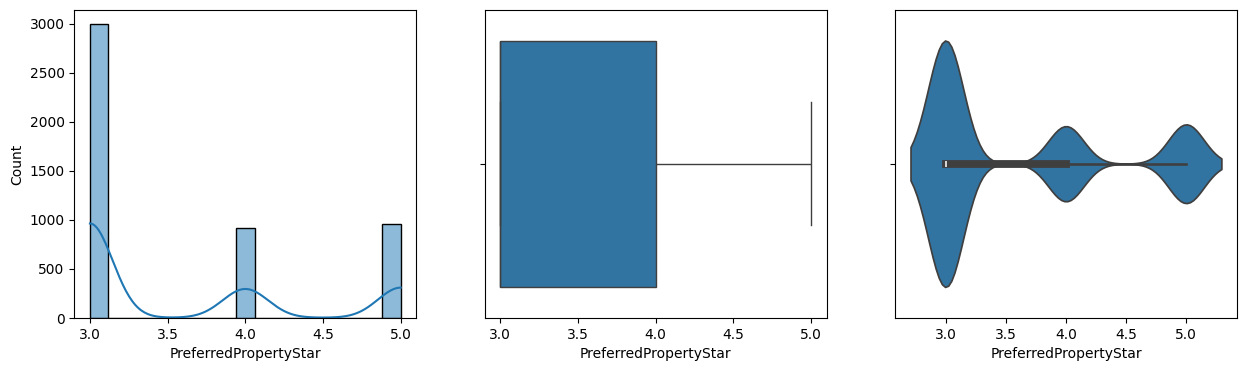

NumberOfTrips 
 count    4748.000000
mean        3.236521
std         1.849019
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        22.000000
Name: NumberOfTrips, dtype: float64
Missing values: 140
Missing Percentage: 2.86


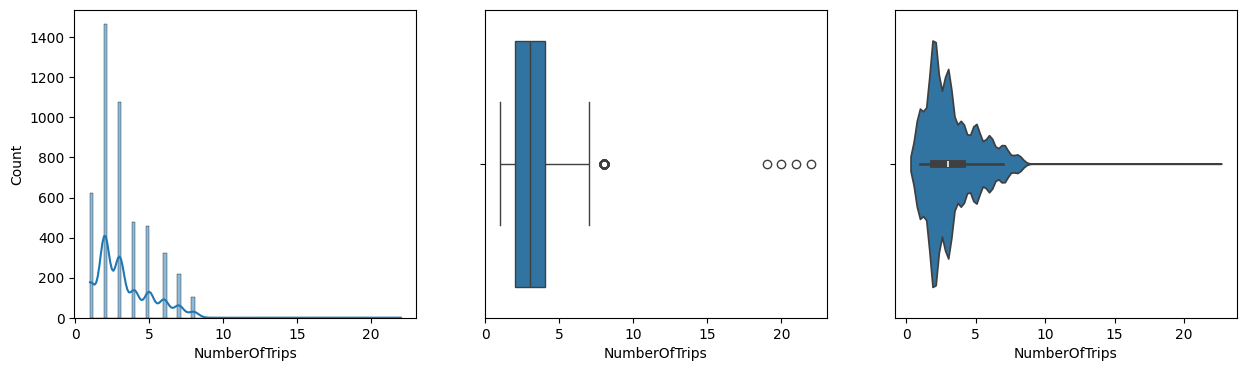

NumberOfChildrenVisiting 
 count    4822.000000
mean        1.187267
std         0.857861
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         3.000000
Name: NumberOfChildrenVisiting, dtype: float64
Missing values: 66
Missing Percentage: 1.35


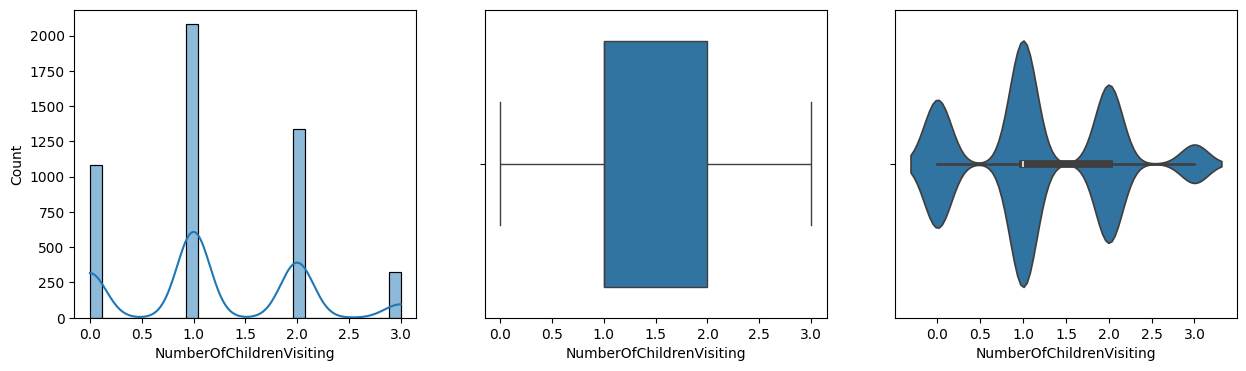

MonthlyIncome 
 count     4655.000000
mean     23619.853491
std       5380.698361
min       1000.000000
25%      20346.000000
50%      22347.000000
75%      25571.000000
max      98678.000000
Name: MonthlyIncome, dtype: float64
Missing values: 233
Missing Percentage: 4.77


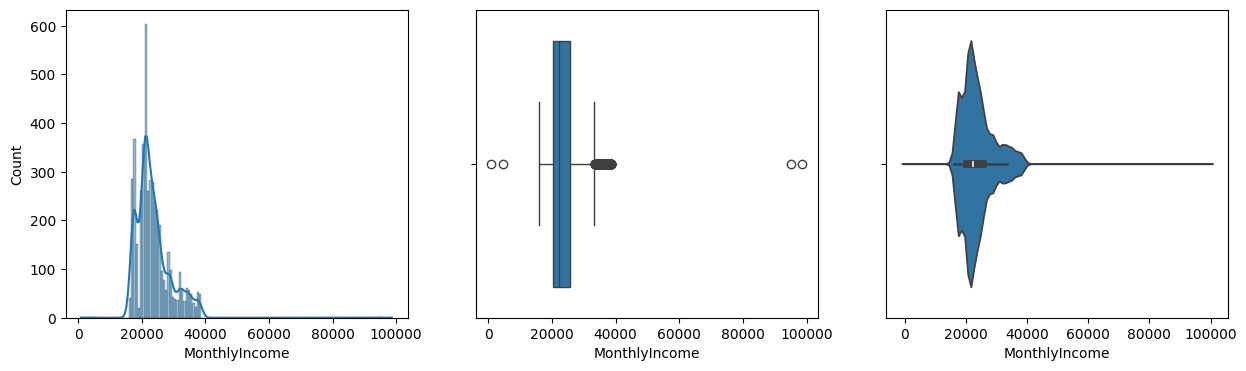

In [10]:
for feature in numeric_null_columns:

    print(feature,"\n",df[feature].describe())
    print("Missing values:", df[feature].isnull().sum())
    print("Missing Percentage:",np.round(df[feature].isnull().mean()*100,2))

    plt.figure(figsize=(15,4))

    plt.subplot(1,3,1)
    sns.histplot(df[feature], kde=True)

    plt.subplot(1,3,2)
    sns.boxplot(x=df[feature])

    plt.subplot(1,3,3)
    sns.violinplot(x=df[feature])

    plt.show()

## if 50% and mean has almost same value => very less no of outliers

In [11]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [12]:
import warnings
warnings.filterwarnings('ignore')
df['Age'].fillna(df['Age'].median(),inplace=True)
df['TypeofContact'].fillna(df['TypeofContact'].mode(),inplace=True)
df['DurationOfPitch'].fillna(df['DurationOfPitch'].median(),inplace=True)
df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].median(),inplace=True)
df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].median(),inplace=True)
df['NumberOfTrips'].fillna(df['NumberOfTrips'].median(),inplace=True)
df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].median(),inplace=True)
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(),inplace=True)

In [13]:
df.isnull().sum()

ProdTaken                    0
Age                          0
TypeofContact               25
CityTier                     0
DurationOfPitch              0
Occupation                   0
Gender                       0
NumberOfPersonVisiting       0
NumberOfFollowups            0
ProductPitched               0
PreferredPropertyStar        0
MaritalStatus                0
NumberOfTrips                0
Passport                     0
PitchSatisfactionScore       0
OwnCar                       0
NumberOfChildrenVisiting     0
Designation                  0
MonthlyIncome                0
dtype: int64

In [14]:
df['TypeofContact'].fillna(df['TypeofContact'].mode()[0],inplace=True)

In [15]:
df['TypeofContact'].mode()[0]

'Self Enquiry'

##  Feature engineering

In [16]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [17]:
df['TotalPersonsVisiting']=df['NumberOfPersonVisiting']+df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfChildrenVisiting','NumberOfPersonVisiting'],axis=1,inplace=True)

In [18]:
## numerical features
num_features=[feature for feature in df.columns if df[feature].dtype != 'O']
print("Num of numerical Features:",len(num_features))

Num of numerical Features: 12


In [19]:
## catagorical features
cat_features=[feature for feature in df.columns if df[feature].dtype == 'O']
print("Num of catagorical Features:",len(cat_features))

Num of catagorical Features: 6


In [20]:
## discrete num features
discrete_features=[feature for feature in num_features if len(df[feature].unique())< 25]
print("Num of discrete Features:",len(discrete_features))

Num of discrete Features: 9


In [21]:
## continuous features
continuous_features=[feature for feature in num_features if len(df[feature].unique())>= 25]
print("Num of continuous Features:",len(continuous_features))

Num of continuous Features: 3


## Train test split and encoding

In [24]:
from sklearn.model_selection import train_test_split
X=df.drop(['ProdTaken'],axis=1)
y=df['ProdTaken']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=91)



In [25]:
cat_features=X.select_dtypes(include='object').columns
num_features=X.select_dtypes(exclude='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder(drop='first')

preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,cat_features),
        ("StandardScaler",numeric_transformer,num_features)
    ]
)

In [26]:
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score,accuracy_score,ConfusionMatrixDisplay,classification_report,recall_score,f1_score,roc_auc_score,roc_curve
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [28]:
models={
    "RandomForest":RandomForestClassifier(),
    "DecesionTree":DecisionTreeClassifier(),
    "Logistic":LogisticRegression(),
    "svc":SVC(),
    "Adaboost ":AdaBoostClassifier()

}

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    ##predict
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    ##training set performance
    train_accuracy=accuracy_score(y_train,y_train_pred)
    train_f1=f1_score(y_train,y_train_pred)
    train_precision=precision_score(y_train,y_train_pred)
    train_recall=recall_score(y_train,y_train_pred)
    train_rocauc_score=roc_auc_score(y_train,y_train_pred)

    ##test set performance
    test_accuracy=accuracy_score(y_test,y_test_pred)
    test_f1=f1_score(y_test,y_test_pred)
    test_precision=precision_score(y_test,y_test_pred)
    test_recall=recall_score(y_test,y_test_pred)
    test_rocauc_score=roc_auc_score(y_test,y_test_pred)

    print(list(models.keys())[i])
    ##Training performance
    print('Model performance for training dataset')
    print('  -Accuracy: {:.4f}'.format(train_accuracy))
    print('  -F1 Score: {:.4f}'.format(train_f1))
    print('  -Precision: {:.4f}'.format(train_accuracy))
    print('  -Recall: {:.4f}'.format(train_recall))
    print('  -Roc Auc Score: {:.4f}'.format(train_rocauc_score))

    print('-----------------------------------')
    
    ## Test performance
    print('Model performance for test dataset')
    print('  -Accuracy: {:.4f}'.format(test_accuracy))
    print('  -F1 Score: {:.4f}'.format(test_f1))
    print('  -Precision: {:.4f}'.format(test_accuracy))
    print('  -Recall: {:.4f}'.format(test_recall))
    print('  -Roc Auc Score: {:.4f}'.format(test_rocauc_score)) 
    print("-*-"*20)  



RandomForest
Model performance for training dataset
  -Accuracy: 1.0000
  -F1 Score: 1.0000
  -Precision: 1.0000
  -Recall: 1.0000
  -Roc Auc Score: 1.0000
-----------------------------------
Model performance for test dataset
  -Accuracy: 0.9376
  -F1 Score: 0.7987
  -Precision: 0.9376
  -Recall: 0.6836
  -Roc Auc Score: 0.8387
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
DecesionTree
Model performance for training dataset
  -Accuracy: 1.0000
  -F1 Score: 1.0000
  -Precision: 1.0000
  -Recall: 1.0000
  -Roc Auc Score: 1.0000
-----------------------------------
Model performance for test dataset
  -Accuracy: 0.9059
  -F1 Score: 0.7486
  -Precision: 0.9059
  -Recall: 0.7740
  -Roc Auc Score: 0.8545
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
Logistic
Model performance for training dataset
  -Accuracy: 0.8414
  -F1 Score: 0.4095
  -Precision: 0.8414
  -Recall: 0.2894
  -Roc Auc Score: 0.6302
-----------------------------------
Model performance for test d

In [37]:


# Define the parameter grid
rf_params = {
    'max_depth': [5, 10, 15, 20, 25, None],
    'max_features': [5, 7, 'auto', 8],
    'min_samples_split': [2, 5, 10, 15, 20],
    'n_estimators': [100, 200, 500, 1000]
}

adaboost_params={
    "n_estimators":[50,60,70,80,90],
    "learning_rate":[0.01,0.05,0.1,0.25,0.5],
}


In [38]:
randomcv_models=[
    ('RF',RandomForestClassifier(),rf_params),
    ('AdaBoost',AdaBoostClassifier(),adaboost_params)
    
]

In [39]:
from sklearn.model_selection import RandomizedSearchCV

model_best_params={

}
for name,model,params in randomcv_models:
    randomcv=RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=100,
        cv=3,
        verbose=2,
        n_jobs=-1
    )
    randomcv.fit(X_train,y_train)
    model_best_params[name]=randomcv.best_params_
for model_name in model_best_params:
    print(f'-----------------Best Params for {model_name} -----------------')
    print(model_best_params[model_name])


Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 25 candidates, totalling 75 fits
-----------------Best Params for RF -----------------
{'n_estimators': 100, 'min_samples_split': 2, 'max_features': 8, 'max_depth': 20}
-----------------Best Params for AdaBoost -----------------
{'n_estimators': 60, 'learning_rate': 0.5}


In [40]:
models={
    "RandomForest":RandomForestClassifier(n_estimators= 200, min_samples_split= 2, max_features= 8, max_depth= None),
    "AdaBoost ":AdaBoostClassifier(n_estimators= 60, learning_rate= 0.5)

}

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    ##predict
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    ##training set performance
    train_accuracy=accuracy_score(y_train,y_train_pred)
    train_f1=f1_score(y_train,y_train_pred)
    train_precision=precision_score(y_train,y_train_pred)
    train_recall=recall_score(y_train,y_train_pred)
    train_rocauc_score=roc_auc_score(y_train,y_train_pred)

    ##test set performance
    test_accuracy=accuracy_score(y_test,y_test_pred)
    test_f1=f1_score(y_test,y_test_pred)
    test_precision=precision_score(y_test,y_test_pred)
    test_recall=recall_score(y_test,y_test_pred)
    test_rocauc_score=roc_auc_score(y_test,y_test_pred)

    print(list(models.keys())[i])
    ##Training performance
    print('Model performance for training dataset')
    print('  -Accuracy: {:.4f}'.format(train_accuracy))
    print('  -F1 Score: {:.4f}'.format(train_f1))
    print('  -Precision: {:.4f}'.format(train_accuracy))
    print('  -Recall: {:.4f}'.format(train_recall))
    print('  -Roc Auc Score: {:.4f}'.format(train_rocauc_score))

    print('-----------------------------------')
    
    ## Test performance
    print('Model performance for test dataset')
    print('  -Accuracy: {:.4f}'.format(test_accuracy))
    print('  -F1 Score: {:.4f}'.format(test_f1))
    print('  -Precision: {:.4f}'.format(test_accuracy))
    print('  -Recall: {:.4f}'.format(test_recall))
    print('  -Roc Auc Score: {:.4f}'.format(test_rocauc_score)) 
    print("-*-"*20)  



RandomForest
Model performance for training dataset
  -Accuracy: 1.0000
  -F1 Score: 1.0000
  -Precision: 1.0000
  -Recall: 1.0000
  -Roc Auc Score: 1.0000
-----------------------------------
Model performance for test dataset
  -Accuracy: 0.9489
  -F1 Score: 0.8408
  -Precision: 0.9489
  -Recall: 0.7458
  -Roc Auc Score: 0.8698
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
AdaBoost 
Model performance for training dataset
  -Accuracy: 0.8391
  -F1 Score: 0.3050
  -Precision: 0.8391
  -Recall: 0.1857
  -Roc Auc Score: 0.5891
-----------------------------------
Model performance for test dataset
  -Accuracy: 0.8436
  -F1 Score: 0.2749
  -Precision: 0.8436
  -Recall: 0.1638
  -Roc Auc Score: 0.5788
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-


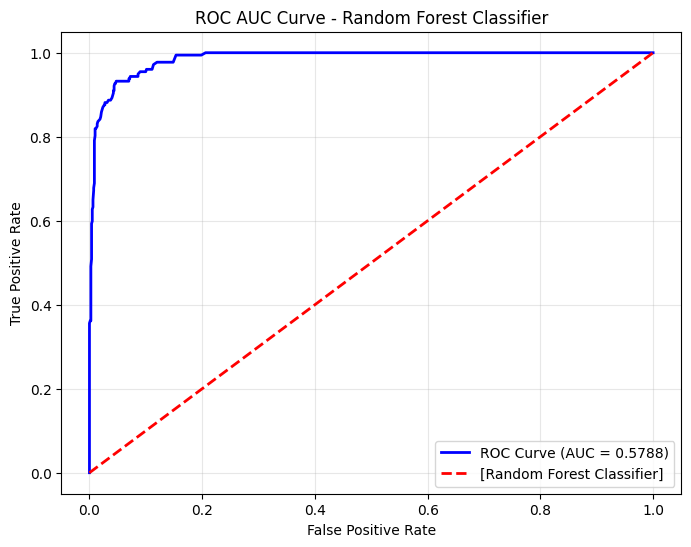

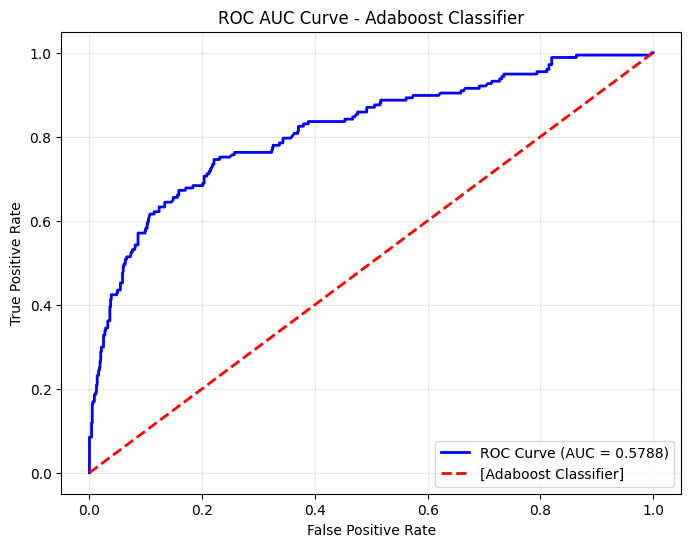

In [44]:

auc_models=[
    {
        'label': "Random Forest Classifier",
        'model':RandomForestClassifier(n_estimators= 200, min_samples_split= 2, max_features= 8, max_depth= None),
        'auc':0.8657

    },
    {
        'label': "Adaboost Classifier",
        'model':AdaBoostClassifier(n_estimators= 60, learning_rate= 0.5),
        'auc':0.5788

    }
]
for algo in auc_models:
    model=algo['model']
    model.fit(X_train,y_train)
    fpr,tpr,threshold=roc_curve(y_test,model.predict_proba(X_test)[:,1])

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {test_rocauc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label=f'[{algo["label"]}]')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC AUC Curve - {algo["label"]}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()